梯度下降收敛分析
A 的特征值: [1.69722436 5.30277564]
条件数 κ = 3.12

收敛性分析:
  α = 0.05: ✅ 收敛 (在稳定范围内)
  α = 0.15: ✅ 收敛 (在稳定范围内)
  α = 0.3: ✅ 收敛 (在稳定范围内)
  α = 0.5: ❌ 可能不收敛或不稳定

条件数对收敛速度的影响


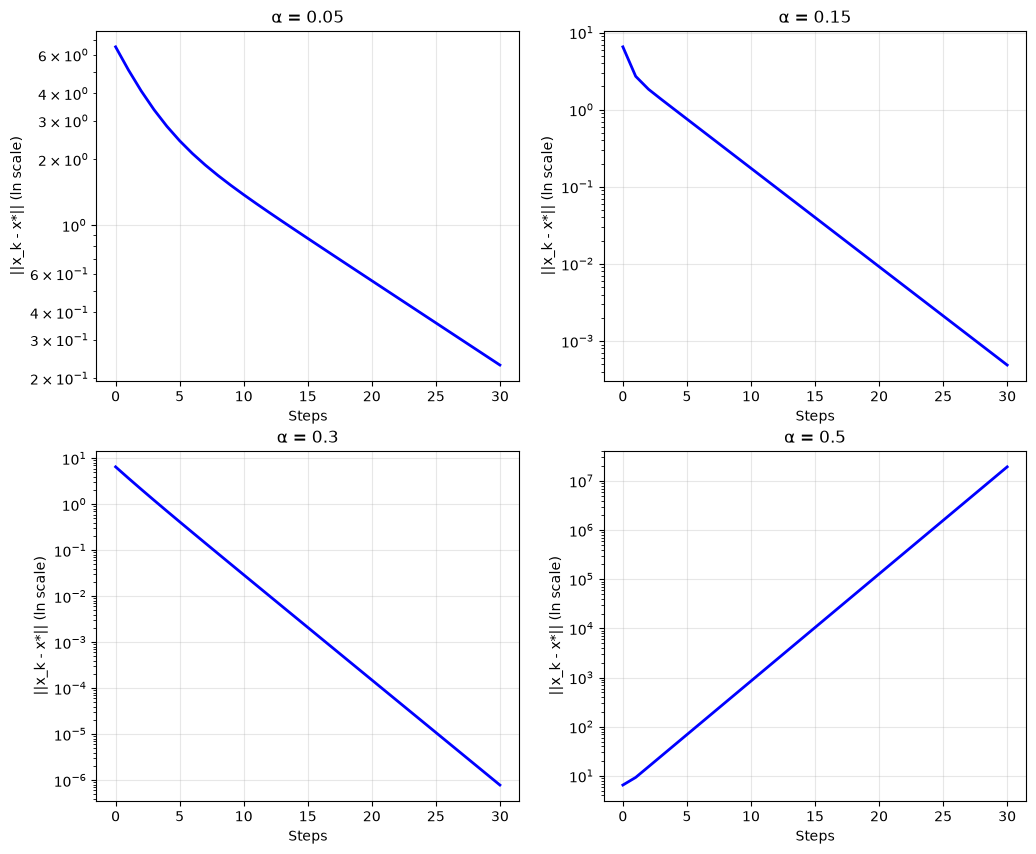

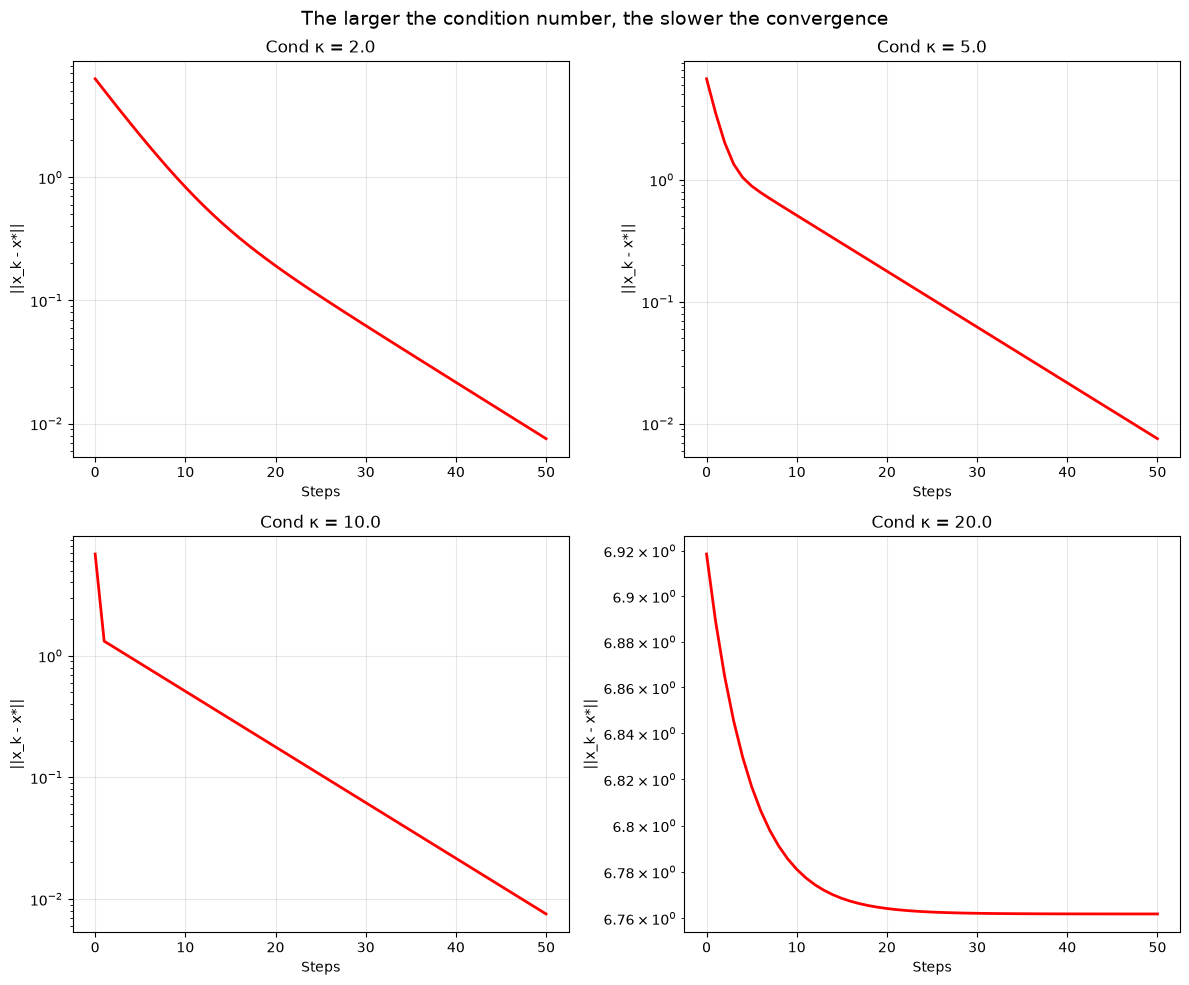

✅ 条件数越大（矩阵越“病态”），梯度下降收敛越慢
💡 预处理（如白化）可以减少条件数，加速收敛


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ---- 定义二次函数 ----
A = np.array([[5, 1], [1, 2]])
b = np.array([3, 1])

eigvals = np.linalg.eigvalsh(A)
lambda_max = np.max(eigvals)
lambda_min = np.min(eigvals)
cond = lambda_max / lambda_min

print("=" * 60)
print("梯度下降收敛分析")
print("=" * 60)
print(f"A 的特征值: {eigvals}")
print(f"条件数 κ = {cond:.2f}")

# ---- 模拟不同学习率 ----
def gradient_descent(A, b, x0, alpha, n_steps=50):
    """梯度下降模拟"""
    x = x0.copy()
    trajectory = [x.copy()]
    for _ in range(n_steps):
        x = x - alpha * (A @ x - b)
        trajectory.append(x.copy())
    return np.array(trajectory)

x0 = np.array([5, 5])

# 不同的学习率
alphas = [0.05, 0.15, 0.3, 0.5]
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for idx, alpha in enumerate(alphas):
    ax = axes[idx // 2, idx % 2]
    trajectory = gradient_descent(A, b, x0, alpha, n_steps=30)
    
    # 计算到最优解的距离
    x_star = np.linalg.solve(A, b)
    errors = np.linalg.norm(trajectory - x_star, axis=1)
    
    ax.semilogy(errors, 'b-', linewidth=2)
    ax.set_xlabel('Steps')
    ax.set_ylabel('||x_k - x*|| (ln scale)')
    ax.set_title(f'α = {alpha}')
    ax.grid(alpha=0.3)

# 判断哪些学习率收敛
print("\n收敛性分析:")
for alpha in alphas:
    if 0 < alpha < 2 / lambda_max:
        print(f"  α = {alpha}: ✅ 收敛 (在稳定范围内)")
    else:
        print(f"  α = {alpha}: ❌ 可能不收敛或不稳定")

# ---- 条件数对收敛速度的影响 ----
print("\n" + "=" * 60)
print("条件数对收敛速度的影响")
print("=" * 60)

# 创建不同条件数的矩阵
cond_values = [2, 5, 10, 20]
alpha_optimal = 0.1  # 固定学习率
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for idx, cond_val in enumerate(cond_values):
    ax = axes[idx // 2, idx % 2]
    
    # 创建一个条件数为 cond_val 的矩阵
    # A = Q @ diag([λ_max, λ_min]) @ Q^T
    lambda_max_c = cond_val
    lambda_min_c = 1
    theta = np.pi / 6
    Q = np.array([[np.cos(theta), -np.sin(theta)],
                  [np.sin(theta), np.cos(theta)]])
    A_c = Q @ np.diag([lambda_max_c, lambda_min_c]) @ Q.T
    b_c = np.array([1, 1])
    
    x_star_c = np.linalg.solve(A_c, b_c)
    trajectory = gradient_descent(A_c, b_c, x0, alpha_optimal, n_steps=50)
    errors = np.linalg.norm(trajectory - x_star_c, axis=1)
    
    ax.semilogy(errors, 'r-', linewidth=2)
    ax.set_xlabel('Steps')
    ax.set_ylabel('||x_k - x*||')
    ax.set_title(f'Cond κ = {cond_val:.1f}')
    ax.grid(alpha=0.3)

# plt.suptitle('条件数越大，收敛越慢', fontsize=14)
plt.suptitle('The larger the condition number, the slower the convergence', fontsize=14)
plt.tight_layout()
plt.show()

print("✅ 条件数越大（矩阵越“病态”），梯度下降收敛越慢")
print("💡 预处理（如白化）可以减少条件数，加速收敛")